In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


In [2]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [6]:

# Parameters
p_cd = 0.0004
t_s = 2
bf_mut = 1e-3  # 10^-3

# # Load data  for lognormal distribution

fraction_mut_null = np.loadtxt(f"data/Supplementary_Fig_6/average_number_of_mutations_no_cd_bf_m_{bf_mut}_t2_{t_s}.txt")
fraction_mut_no_jump = np.loadtxt(f"data/Supplementary_Fig_6/average_number_of_mutations_cd_{p_cd}_bf_m_{bf_mut}_t2_{t_s}_no_jump.txt")
fraction_mut_jump = np.loadtxt(f"data/Supplementary_Fig_6/average_number_of_mutations_cd_{p_cd}_bf_m_{bf_mut}_t2_{t_s}_jump.txt")
fraction_mut_cd = np.loadtxt(f"data/Supplementary_Fig_6/average_number_of_mutations_single_inidiv_{bf_mut}.txt")

# Maximum slopes distribution
max_slopes_null = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_null_bf_m_{bf_mut}_t2_{t_s}.txt")
max_slopes_no_jump = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_no_jump_cd_{p_cd}_bf_m_{bf_mut}_t2_{t_s}.txt")
max_slopes_jump = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_jump_cd_{p_cd}_bf_m_{bf_mut}_t2_{t_s}.txt")

# Shared data
fraction_mut_null_shared = fraction_mut_null
fraction_mut_cd_shared = fraction_mut_cd
max_slopes_null_shared = max_slopes_null
# same scale for all populations
# Load data  for gamma distribution
fraction_mut_no_jump_gamma = np.loadtxt(f"data/Supplementary_Fig_6/fraction_mut_variant_no_jump_gamma.txt")
###
max_slopes_no_jump_gamma = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_no_jump_gamma.txt")
max_slopes_jump_gamma = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_jump_gamma.txt")

# Load data for logskewnormal distribution

fraction_mut_no_jump_sk = np.loadtxt(f"data/Supplementary_Fig_6/fraction_mut_variant_no_jump_skew_log_normal.txt")
fraction_mut_jump_sk = np.loadtxt(f"data/Supplementary_Fig_6/fraction_mut_variant_jump_skew_log_normal.txt")
###
max_slopes_no_jump_sk = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_no_jump_skew_log_normal.txt")
max_slopes_jump_sk = np.loadtxt(f"data/Supplementary_Fig_6/max_slope_jump_skew_log_normal.txt")

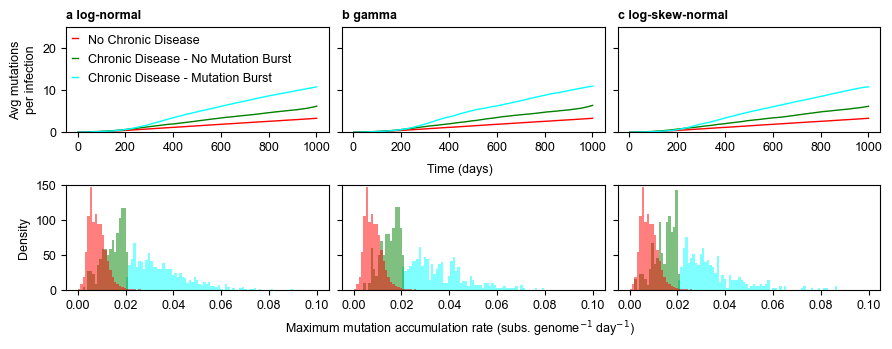

In [4]:
# define plotwidth
def cm2inch(x): return float(x)/2.54
plotwidth    = cm2inch(8.90)

T = 1000

# Distributions
distributions = ["log-normal", "gamma", "log-skew-normal"]
panel_labels = ['a', 'b', 'c']

# Dictionaries with your data
fraction_mut_no_jump_dict = {
    "log-normal": fraction_mut_no_jump,
    "gamma": fraction_mut_no_jump_gamma,
    "log-skew-normal": fraction_mut_no_jump_sk
}
fraction_mut_jump_dict = {
    "log-normal": fraction_mut_jump,
    "gamma": fraction_mut_jump_gamma,
    "log-skew-normal": fraction_mut_jump_sk
}
max_slopes_no_jump_dict = {
    "log-normal": max_slopes_no_jump,
    "gamma": max_slopes_no_jump_gamma,
    "log-skew-normal": max_slopes_no_jump_sk
}
max_slopes_jump_dict = {
    "log-normal": max_slopes_jump,
    "gamma": max_slopes_jump_gamma,
    "log-skew-normal": max_slopes_jump_sk
}

# Shared data
fraction_mut_null_shared = fraction_mut_null
max_slopes_null_shared = max_slopes_null

# Plot settings
colors_time = ['red', 'green', 'cyan']
labels_time = ['No Chronic Disease',
               'Chronic Disease - No Mutation Burst',
               'Chronic Disease - Mutation Burst']
colors_hist = ['red', 'green', 'cyan']
labels_hist = ['Non CD', 'CD - No Mutation Burst', 'CD - Mutation Burst']
bins = np.linspace(0, 0.1, 100)

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(3*plotwidth, plotwidth), constrained_layout=False)
fig.subplots_adjust(top=0.9, bottom=0.15, hspace=0.50, wspace=0.05)

for col, dist in enumerate(distributions):
    dist_label = f"{panel_labels[col]} {dist}"

    # --- Top row: time-course mutation plot ---
    ax_time = axs[0, col]
    ax_time.plot(range(1, T+2), fraction_mut_null_shared, color=colors_time[0], lw=1, 
                 label=labels_time[0] if (0,0) == (0, col) else '')
    ax_time.plot(range(1, T+2), fraction_mut_no_jump_dict[dist], color=colors_time[1], lw=1, 
                 label=labels_time[1] if (0,0) == (0, col) else '')
    ax_time.plot(range(1, T+2), fraction_mut_jump_dict[dist], color=colors_time[2], lw=1, 
                 label=labels_time[2] if (0,0) == (0, col) else '')
    
    ax_time.set_ylim([0.00, 25])
    
    if col == 0:
        ax_time.set_ylabel("Avg mutations\nper infection")
        ax_time.legend(loc='upper left', frameon=False,handlelength=0.5, handleheight=1.0,borderpad=0.01)
    else:
        ax_time.set_ylabel('')
        ax_time.set_yticklabels([])
    
    #ax_time.set_xlabel('Time (days)')
    ax_time.grid(False)
    ax_time.set_title(dist_label, loc='left', weight='bold')

    # --- Bottom row: histogram of max slopes ---
    ax_hist = axs[1, col]
    ax_hist.hist(max_slopes_jump_dict[dist], bins=bins, density=True, alpha=0.5, color=colors_hist[2], 
                 label=labels_hist[2] if (0,0) == (0, col) else '')
    ax_hist.hist(max_slopes_no_jump_dict[dist], bins=bins, density=True, alpha=0.5, color=colors_hist[1], 
                 label=labels_hist[1] if (0,0) == (0, col) else '')
    ax_hist.hist(max_slopes_null_shared, bins=bins, density=True, alpha=0.5, color=colors_hist[0], 
                 label=labels_hist[0] if (0,0) == (0, col) else '')
    
    #ax_hist.set_xlabel('Max slope values')
    if col == 0:
        ax_hist.set_ylabel('Density')
    else:
        ax_hist.set_ylabel('')
        ax_hist.set_yticklabels([])
    
    ax_hist.set_ylim(0, 150)
    ax_hist.grid(False)
    
fig.text(0.5, 0.51, 'Time (days)', ha='center', va='top')   # top row
fig.text(0.5, 0.01, 'Maximum mutation accumulation rate (subs. genome$^{-1}$ day$^{-1}$)', 
         ha='center', va='bottom')  # bottom row

plt.show()